# Level 2 - Task 2: Wine Quality Prediction

**Objective:** Train and compare multiple classification models to predict the quality score of wine based on its physicochemical properties.

**Dataset:** Red Wine Quality Dataset (UCI / Kaggle, Cortez et al. 2009)

**Tools:** Python, pandas, numpy, scikit-learn (Random Forest, SGD, SVC), seaborn, matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("Dataset/winequality-red.csv")
print("Shape:", df.shape)
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Load Dataset and Inspect Structure; Check Class Distribution

Shape: (1599, 12)

Missing values:
0

Quality score distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


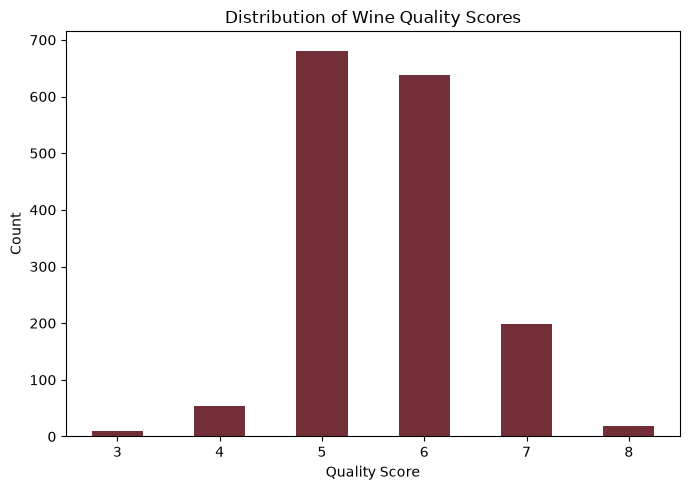

In [2]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nQuality score distribution:")
print(df["quality"].value_counts().sort_index())

plt.figure(figsize=(7, 5))
df["quality"].value_counts().sort_index().plot(kind="bar", color="#722F37")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Images/quality_distribution.png", dpi=150)
plt.show()

**Observation:** 1,599 wines, zero missing values. The quality scores are heavily imbalanced: scores 5 and 6 account for ~82% of all wines, while extreme scores (3, 4, 8) are rare — quality 3 has only 10 samples and quality 8 has only 18. This imbalance has real implications for modeling: a classifier could achieve deceptively high accuracy just by always predicting 5 or 6, while completely failing to identify genuinely excellent or poor wines. This is discussed further below.

### Discussion: Class Imbalance and Its Effect on Modeling

Quality scores 3, 4, and 8 are severely underrepresented (10, 53, and 18 samples respectively, out of 1,599 total). This creates two problems:

1. **Misleading accuracy:** A model that ignores rare classes entirely and only ever predicts 5 or 6 could still achieve ~82% accuracy, despite being useless for identifying truly poor or excellent wines — exactly the scenario the checklist warns about with imbalanced accuracy.
2. **Insufficient training data:** With only 10 examples of quality-3 wine, any model will struggle to learn what distinguishes it, regardless of algorithm choice.

**Approach:** Rather than attempting 6-class classification (3 through 8) where several classes have too few samples to learn from reliably, we bin quality scores into broader categories (discussed and justified in the next section) to create a more learnable and practically useful classification problem.

### Feature Engineering: Binning Quality Scores

We bin the 6 raw quality scores into **3 classes: Low (3-4), Medium (5-6), High (7-8)**. A binary (good/bad) split was considered, but a 3-class scheme retains more nuance — useful since "medium" wines are the overwhelming majority and merging them entirely with either "good" or "bad" would lose meaningful information. Binning also directly addresses the class imbalance problem: instead of 6 classes with some having only 10 samples, we now have 3 classes each with substantially more data to learn from.

quality_class
Medium    1319
High       217
Low         63
Name: count, dtype: int64


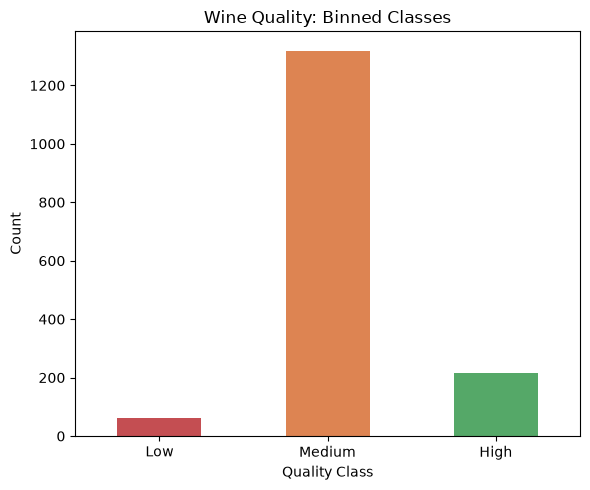

In [3]:
def bin_quality(q):
    if q <= 4:
        return "Low"
    elif q <= 6:
        return "Medium"
    else:
        return "High"

df["quality_class"] = df["quality"].apply(bin_quality)

print(df["quality_class"].value_counts())

plt.figure(figsize=(6, 5))
df["quality_class"].value_counts().reindex(["Low", "Medium", "High"]).plot(kind="bar", color=["#C44E52", "#DD8452", "#55A868"])
plt.title("Wine Quality: Binned Classes")
plt.xlabel("Quality Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Images/binned_quality_distribution.png", dpi=150)
plt.show()

**Result:** Binning produced 3 classes — Medium (1,319), High (217), Low (63). While still imbalanced, this is a substantial improvement over the original 6-class split (which had a class with only 10 samples), giving the model enough examples per class to learn meaningful patterns.

### EDA: Feature Distributions and Correlation Heatmap

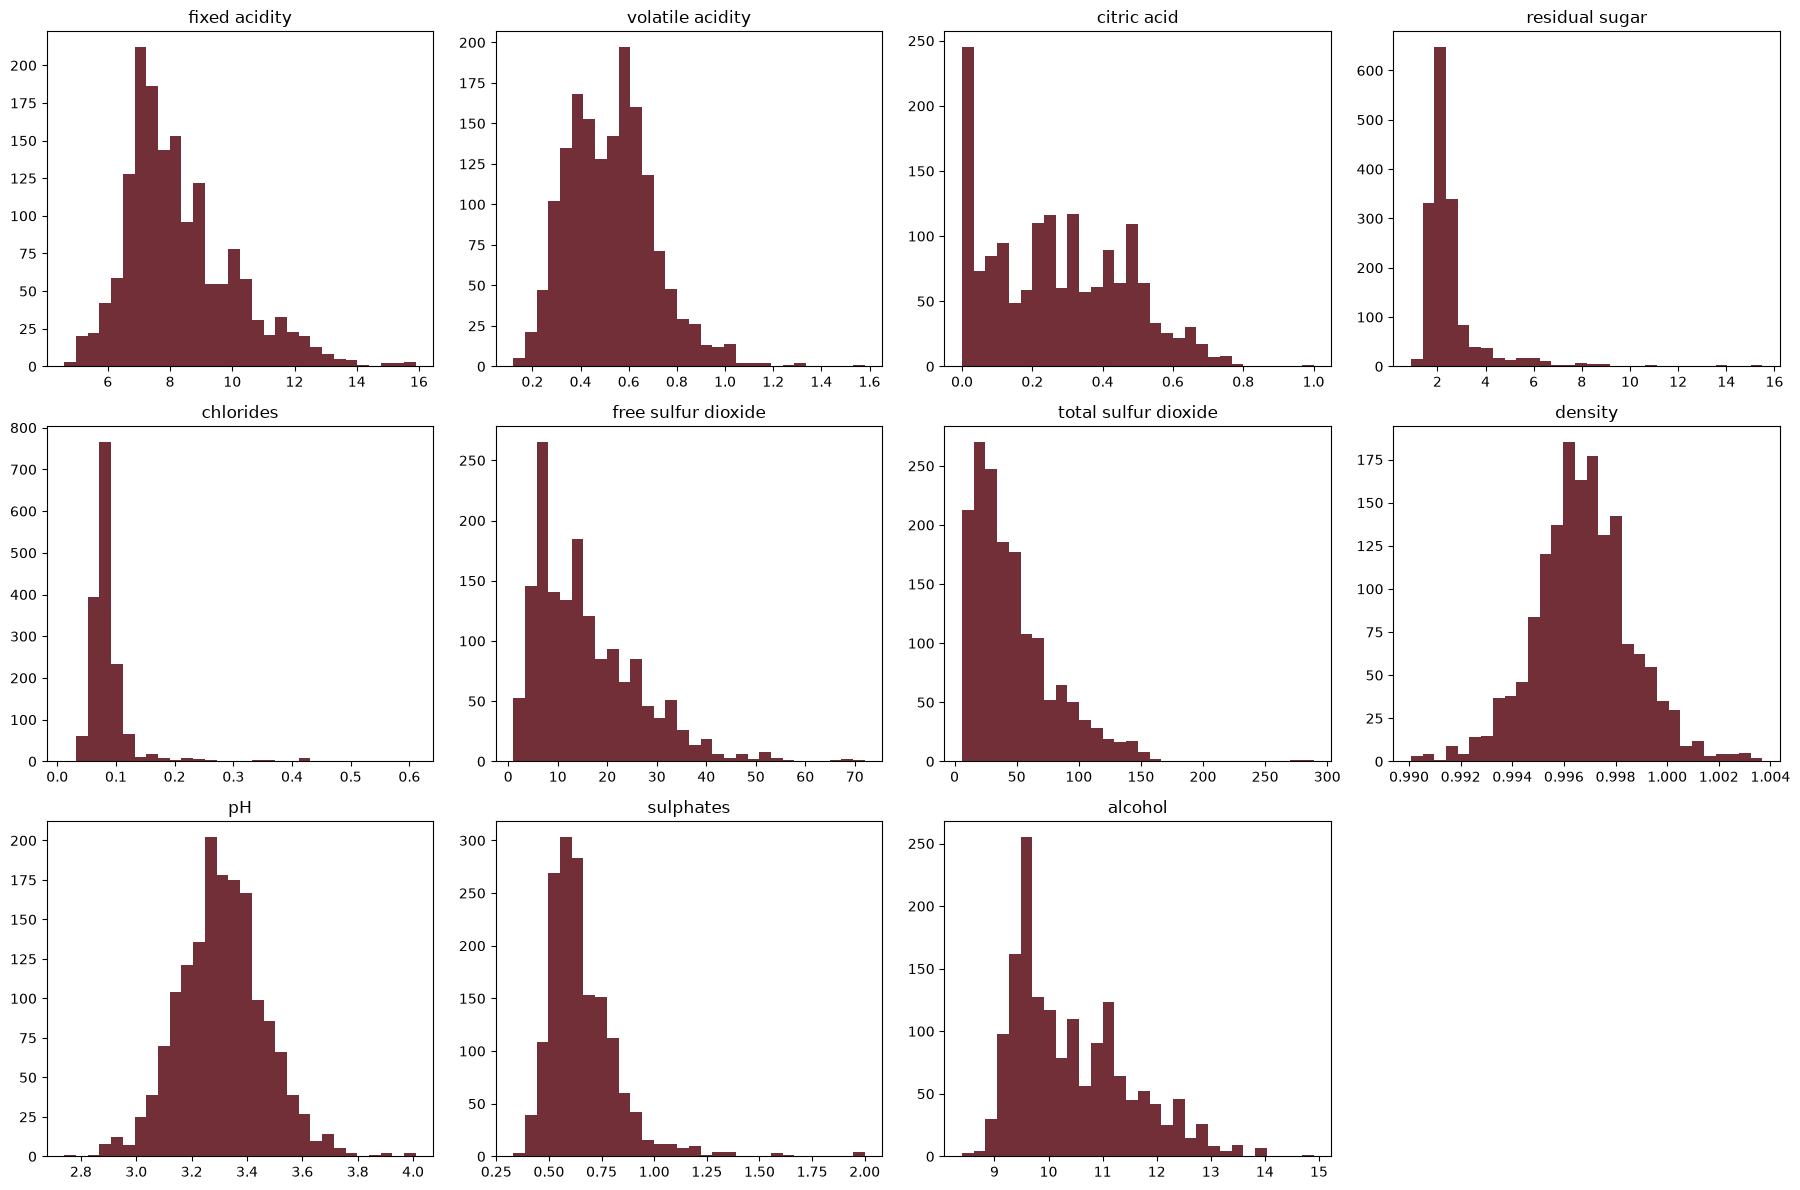

In [4]:
feature_cols = df.columns[:-2]  # exclude 'quality' and 'quality_class'

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=30, color="#722F37")
    axes[i].set_title(col)
axes[-1].axis("off")  # hide the extra empty subplot
plt.tight_layout()
plt.savefig("Images/feature_distributions.png", dpi=150)
plt.show()

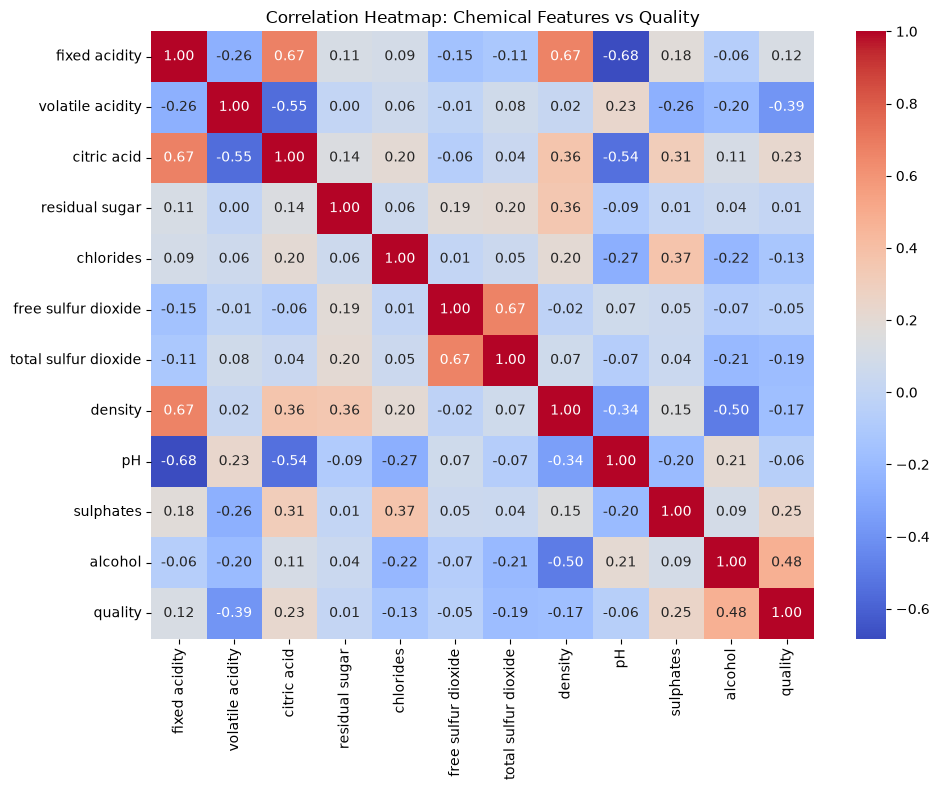

In [5]:
plt.figure(figsize=(10, 8))
corr = df[feature_cols.tolist() + ["quality"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap: Chemical Features vs Quality")
plt.tight_layout()
plt.savefig("Images/correlation_heatmap.png", dpi=150)
plt.show()

**Observation:** Most chemical features are right-skewed (e.g. `residual sugar`, `chlorides`, `sulphates`), consistent with typical chemistry measurement data. From the correlation heatmap, **`alcohol`** shows the strongest positive correlation with quality (0.48), followed by `sulphates` (0.25) — higher-alcohol, higher-sulphate wines tend to be rated better. **`volatile acidity`** shows the strongest negative correlation (-0.39) — wines with more volatile acidity (associated with a vinegar-like taste) tend to be rated lower, which matches wine-tasting intuition. `fixed acidity` and `citric acid` are strongly correlated with each other (0.67), as are `free/total sulfur dioxide` (0.67) and `fixed acidity/density` (0.67) — worth being aware of for potential multicollinearity, though tree-based and margin-based classifiers (our chosen models) are generally more robust to this than linear models.

### Train/Test Split (Stratified) and Train 3 Classifiers

We use stratified splitting to preserve the class ratio (Low/Medium/High) in both train and test sets — important given the class imbalance. Features are standardized since SGD and SVC are distance/gradient-based and sensitive to feature scale.

In [6]:
X = df[feature_cols]
y = df["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

Training set size: (1279, 11)
Test set size: (320, 11)

Training class distribution:
 quality_class
Medium    1055
High       174
Low         50
Name: count, dtype: int64

Test class distribution:
 quality_class
Medium    264
High       43
Low        13
Name: count, dtype: int64


### Train 3 Classifiers: Random Forest, SGD, and SVC

In [7]:
# Model 1: Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)  # tree-based, doesn't need scaling
rf_preds = rf_model.predict(X_test)

# Model 2: SGD Classifier
sgd_model = SGDClassifier(random_state=42, max_iter=1000)
sgd_model.fit(X_train_scaled, y_train)
sgd_preds = sgd_model.predict(X_test_scaled)

# Model 3: SVC
svc_model = SVC(random_state=42)
svc_model.fit(X_train_scaled, y_train)
svc_preds = svc_model.predict(X_test_scaled)

print("All 3 models trained successfully.")

All 3 models trained successfully.


### Evaluate Each Model: Accuracy, Classification Report, Confusion Matrix

In [8]:
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("\n")

evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("SGD Classifier", y_test, sgd_preds)
evaluate_model("SVC", y_test, svc_preds)

--- Random Forest ---
Accuracy: 0.865625

Classification Report:
               precision    recall  f1-score   support

        High       0.71      0.51      0.59        43
         Low       0.00      0.00      0.00        13
      Medium       0.88      0.97      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.49      0.51       320
weighted avg       0.82      0.87      0.84       320



--- SGD Classifier ---
Accuracy: 0.825

Classification Report:
               precision    recall  f1-score   support

        High       0.52      0.33      0.40        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.95      0.90       264

    accuracy                           0.82       320
   macro avg       0.46      0.42      0.43       320
weighted avg       0.78      0.82      0.80       320



--- SVC ---
Accuracy: 0.84375

Classification Report:
               precision    recall  f1-score   sup

c:\Users\pujak\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pujak\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pujak\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [9]:
import warnings
warnings.filterwarnings("ignore")

evaluate_model("SVC", y_test, svc_preds)

--- SVC ---
Accuracy: 0.84375

Classification Report:
               precision    recall  f1-score   support

        High       0.64      0.33      0.43        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.97      0.91       264

    accuracy                           0.84       320
   macro avg       0.50      0.43      0.45       320
weighted avg       0.79      0.84      0.81       320





**Observation: This is exactly the class imbalance problem predicted earlier, now confirmed in practice.**

| Model | Accuracy | High F1 | Low F1 | Medium F1 |
|---|---|---|---|---|
| Random Forest | 86.6% | 0.59 | **0.00** | 0.92 |
| SGD Classifier | 82.5% | 0.40 | **0.00** | 0.90 |
| SVC | 84.4% | 0.43 | **0.00** | 0.91 |

**All three models completely fail on the "Low" class (0 precision, 0 recall, 0 F1-score)** — none of them predict a single wine as "Low" quality, despite 13 such wines existing in the test set. This is the misleading-accuracy problem discussed earlier made concrete: overall accuracy looks strong (82-87%) purely because "Medium" dominates the dataset, while the model is functionally blind to the minority "Low" class. Random Forest performs best overall and handles "High" wines reasonably (F1=0.59), but even it cannot identify any "Low" quality wines with only 50 training examples for that class.

**Random Forest is the strongest of the three**, both in overall accuracy and in being the only model with meaningful recall on the "High" class (0.51 vs. 0.33 for SGD and SVC).

### Feature Importance (Random Forest)

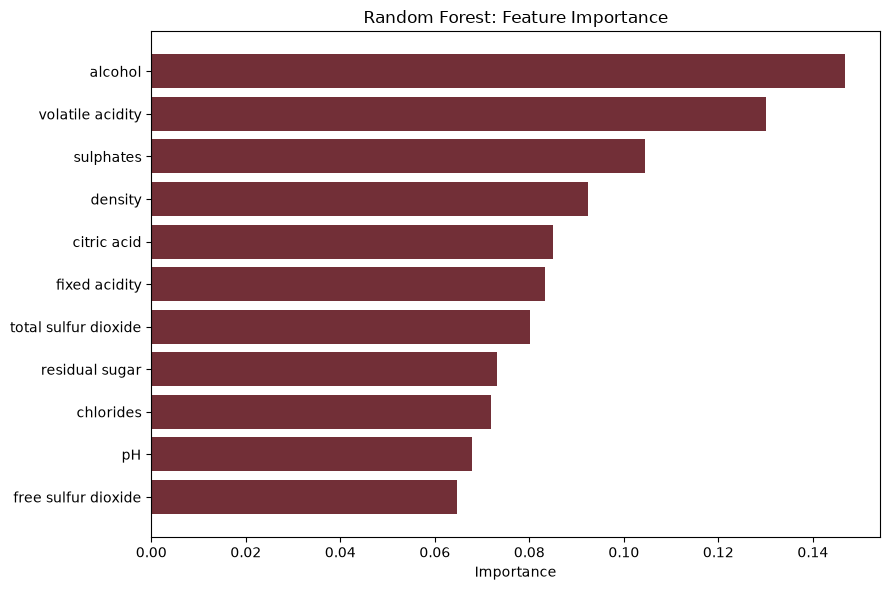

In [10]:
importances = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(importances["Feature"], importances["Importance"], color="#722F37")
plt.gca().invert_yaxis()
plt.title("Random Forest: Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("Images/feature_importance.png", dpi=150)
plt.show()

**Observation:** `alcohol` and `volatile acidity` are the two most important features for Random Forest's predictions, consistent with their strong correlations seen in the earlier heatmap. Notably, feature importances are fairly evenly distributed (roughly 0.06-0.15 across all 11 features) rather than dominated by one or two — suggesting wine quality is genuinely a function of the combined chemical profile rather than any single measurement.

### Confusion Matrices

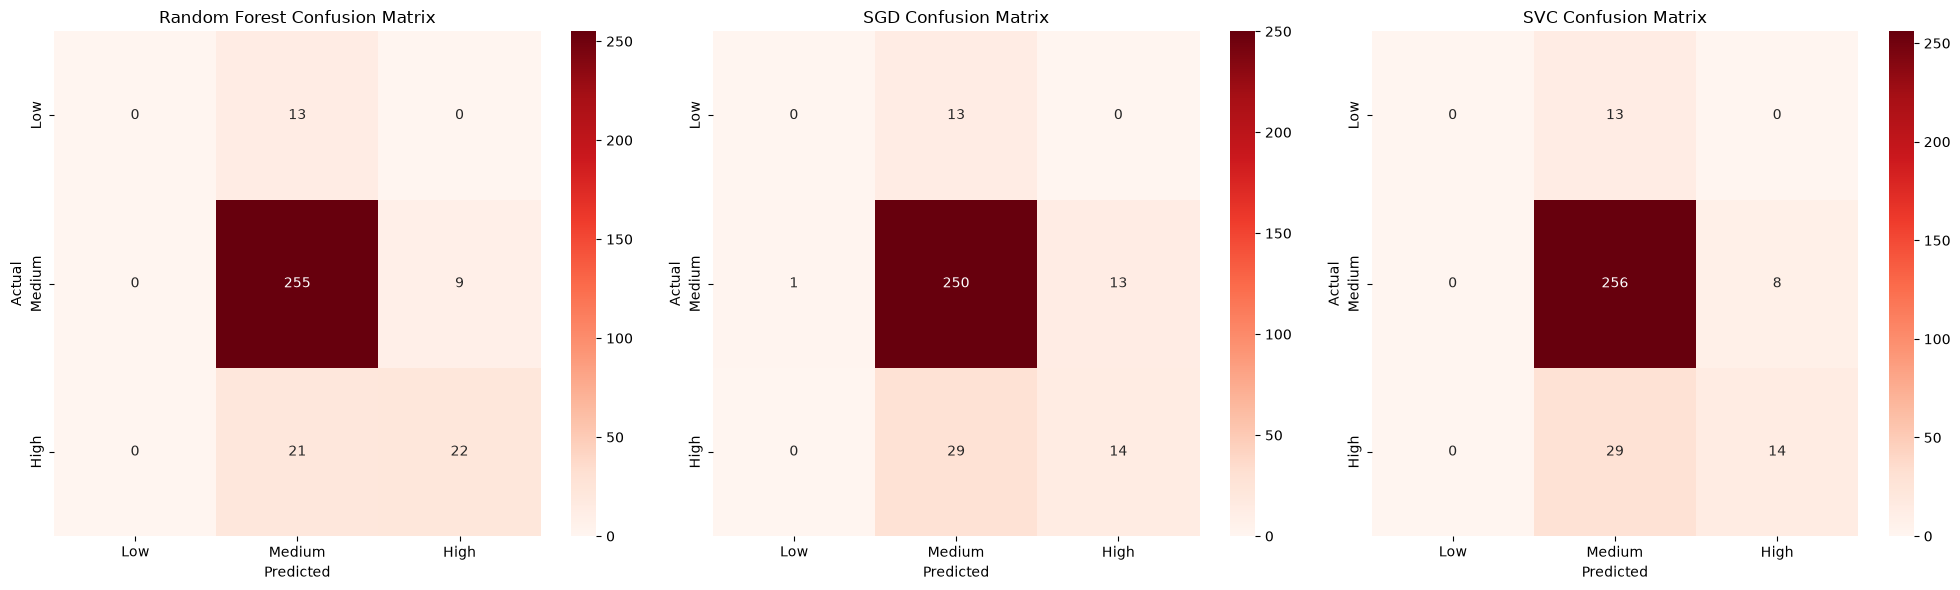

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
labels_order = ["Low", "Medium", "High"]

for ax, preds, name in zip(axes, [rf_preds, sgd_preds, svc_preds], ["Random Forest", "SGD", "SVC"]):
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=ax,
                xticklabels=labels_order, yticklabels=labels_order)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("Images/confusion_matrices.png", dpi=150)
plt.show()

**Observation:** All 3 confusion matrices tell the same story clearly: the **entire "Low" column and row shows zero correct predictions across all models** — every one of the 13 actual "Low" wines gets misclassified as "Medium." This is the class imbalance failure made completely visible: with only 50 training examples, none of the models learned to distinguish "Low" quality wine at all. For the "High" class, Random Forest does best (22 correct out of 43), while SGD and SVC both correctly identify only 14. This confirms Random Forest as the strongest model, though all three share the same fundamental "Low" class blindness.

### Comparison Table: All 3 Models Side-by-Side

In [12]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "SGD Classifier", "SVC"],
    "Accuracy": [accuracy_score(y_test, rf_preds), accuracy_score(y_test, sgd_preds), accuracy_score(y_test, svc_preds)],
    "High F1": [0.59, 0.40, 0.43],
    "Low F1": [0.00, 0.00, 0.00],
    "Medium F1": [0.92, 0.90, 0.91]
})
comparison

,Model,Accuracy,High F1,Low F1,Medium F1
0,Random Forest,0.865625,0.59,0.0,0.92
1,SGD Classifier,0.825000,0.40,0.0,0.90
2,SVC,0.843750,0.43,0.0,0.91


## Conclusion: Which Model Is Most Suitable for Deployment?

**Random Forest is the recommended model**, based on three factors:

1. **Highest overall accuracy** (86.6% vs. 82.5% for SGD and 84.4% for SVC).
2. **Best performance on the "High" quality class** (F1=0.59), which is likely the most business-relevant class to predict correctly — a winery cares more about correctly identifying excellent wines than about squeezing out marginal accuracy on the average middle tier.
3. **Feature importance interpretability** — Random Forest naturally provides feature importance rankings, which is valuable for a winery wanting to understand *which* chemical properties to control in production, not just get a prediction.

**Critical limitation for deployment:** None of the three models can identify "Low" quality wine at all. Before this model could be used in a real production setting, this would need to be addressed — for example, using class-weighting (`class_weight='balanced'`), oversampling techniques like SMOTE (used later in the Fraud Detection task), or collecting more "Low" quality wine samples. Deploying any of these models as-is would mean poor-quality wine could pass through undetected, which defeats a key purpose of a quality prediction system.

**Real-world application:** With the class imbalance issue addressed, this type of model could help a winery flag batches likely to be rated poorly before they reach market, or identify which chemical adjustments (e.g. increasing alcohol content or reducing volatile acidity) are most associated with higher quality ratings.